In [1]:
%load_ext autoreload
%autoreload 2

import json
import os
import yaml
from pathlib import Path
from dask.distributed import Client
import dask.dataframe as dd
import networkx as nx
import sys
import pandas as pd


import ipycytoscape
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import intervals
import pygtrie
import seaborn as sns
import gc


/usr/workspace/pandey2/DFT/envDFT/lib/python3.9/site-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [2]:
use_local=False
if not use_local:
    with open(f'/g/g91/pandey2/.dftracer/configuration.yaml', 'r') as file:
        dlp_yaml = yaml.safe_load(file)
        app_root = dlp_yaml["app"]
else:
    app_root = str(Path(os.getcwd()).parent.parent)
sys.path.insert(0, app_root)

import dfanalyzer
print(dfanalyzer.__file__)
from dfanalyzer.main import DFAnalyzer,get_dft_configuration,update_dft_configuration,setup_logging,setup_dask_cluster, reset_dask_cluster, get_dft_configuration
from dfanalyzer.graph_visualization.cytoscape import GraphFunctions, CytoGraph
from dfanalyzer.graph1 import DFGrepInterference, DFGrepWorkflow 

if not use_local:
    dask_run_dir = os.path.join(app_root, "dfanalyzer", "dask", "run_dir")
    with open (os.path.join(dask_run_dir, f"scheduler_{os.getenv('USER')}.json"), "r") as f:
        dask_scheduler = json.load(f)["address"]
else:
    dask_scheduler = None

# App Name
# app_name = "montage-pegasus-2mass-2deg-4node" #cosmoflow cm1
# app_name = "1000_genome_pegasus_node_16"
# app_name = "cm1"
# app_name = "deepspeed-dlio-step100"
# app_name = "bert"
app_name = "unet3d"

condition_fn = None #

if app_name == "cm1":
    filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.5-develop/corona/cm1/APP/node-32/v1/COMPACT/*.pfw.gz"
    cp_dir = "/p/lustre3/pandey2/logs/results_checkpoint"

elif app_name == "cosmoflow":
    # filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.5-develop/corona/cosmoflow/dlio-v100/node-16/v1/COMPACT/*.pfw.gz"
    filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.5-develop/corona/cosmoflow/dlio-v100/node-4/v1/COMPACT/*1*.pfw.gz"
    cp_dir =  "/p/lustre3/pandey2/logs/results_checkpoint"

elif app_name == "deepspeed-dlio-step100":
    filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.6-develop/corona/megatron-deepspeed/dlio-step100/node-16/v1/COMPACT/*.pfw.gz"
    filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.6-develop/corona/megatron-deepspeed/dlio-scr-step100/node-16/v1/COMPACT/*.pfw.gz"
    cp_dir =  "/p/lustre3/pandey2/logs/results_checkpoint"

elif app_name == "montage-mpi-2mass-7deg":
    filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.5-develop/corona/montage/mpi-2mass-7deg/node-16/v1/RAW/*.pfw.gz"
    cp_dir =  "/p/lustre3/pandey2/logs/results_checkpoint"

elif app_name =="montage-pegasus-2mass-2deg-4node":
    # filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.5-develop/corona/montage/pegasus-2mass-2deg/node-4/v1/COMPACT/*.pfw.gz"
    filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.5-develop/corona/montage/pegasus-2mass-2deg/node-4/v1/RAW/*.pfw.gz"
    cp_dir =  "/p/lustre3/pandey2/logs/results_checkpoint"

elif app_name == "resnet50":
    filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.5-develop/corona/resnet50/dlio-v100/node-4/v1/COMPACT/*.pfw.gz"
    cp_dir =  "/p/lustre3/pandey2/logs/results_checkpoint"

elif app_name == "unet3d":
    filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.5-develop/corona/unet3d/dlio-v100/node-16/v2/COMPACT/*.pfw.gz"
    cp_dir =  "/p/lustre3/pandey2/logs/results_checkpoint"

elif app_name == "bert":
    filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.5-develop/corona/bert/v100/node-16/v1/COMPACT/*.pfw.gz"
    cp_dir =  "/p/lustre3/pandey2/logs/results_checkpoint"

elif app_name == "1000_genome_pegasus_node_16":
    filename = "/p/lustre3/iopp/dftracer-traces-lfs/v1.0.5-develop/corona/1000-genome/pegasus/node-16/v3/COMPACT/*.pfw.gz"
    cp_dir =  "/p/lustre3/pandey2/logs/results_checkpoint"
    
else:
    raise Exception("Unknown App name")


# Configuration 4 update log file dlp -> df
conf = update_dft_configuration(dask_scheduler=dask_scheduler, verbose=True, debug=True,
                                log_file=f"./dft_{os.getenv('USER')}.log", rebuild_index=False, time_approximate=True, 
                                host_pattern=r'lassen(\d+)', time_granularity=1e6, skip_hostname=True, conditions=condition_fn)
conf = get_dft_configuration()


# Setup
setup_logging()
setup_dask_cluster()
reset_dask_cluster()

[INFO] [19:21:47] Initialized Client with 192 workers and link http://134.9.71.27:8787/status [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:769]


/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/__init__.py


[INFO] [19:21:53] Restarting all workers [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:761]


In [3]:
def all_mount_points():
    with open("/proc/mounts", "r") as file:
        mount_points = [line.split()[1] for line in file]
    with open("/usr/workspace/pandey2/lassen_mounts", "r") as file:
        mount_p = [line.split()[1] for line in file]
    return mount_points+mount_p

mount_points = all_mount_points()
trie = pygtrie.StringTrie(zip(mount_points, [True] * len(mount_points)))


In [4]:
def cols_function(json_object, current_dict, time_approximate,condition_fn,load_data):
    d = {}
    def find_mount_point(path,trie):
        mount_point = trie.longest_prefix(path)
        if mount_point:
            return mount_point.key
        return '/'.join(path.split('/', 3)[:3])

    if "M" == json_object["ph"] and "FH" == json_object["name"] and "args" in json_object and "name" in json_object["args"]:
        d["mount_point"] = find_mount_point(trie=load_data["mount_point"],path=json_object["args"]["name"])
    if "args" in json_object and "M" != json_object["ph"]:
        if "ret" in json_object["args"]:
            d["size"] = int(json_object["args"]["ret"]) 
    return d

load_cols = {'size': "int64[pyarrow]" }
load_cols_metadata = {"FH":{'mount_point':"string[pyarrow]" }}

In [24]:
reset_dask_cluster()

[INFO] [13:19:55] Restarting all workers [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:761]


In [5]:
analyzer = DFAnalyzer(filename,load_fn=cols_function, load_cols=load_cols, load_data={"mount_point":trie}, metadata_cols = load_cols_metadata)

[INFO] [19:22:04] Created index for 2 files [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:428]
[INFO] [19:22:04] Total size of all files are <dask.bag.core.Item object at 0x1554ab45fc10> bytes [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:430]
[INFO] [19:22:04] test debug [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:433]


KilledWorker: Attempted to run task ('get_linenumber-dbb04281c5db1e00e9e162f80c2735dd', 0) on 4 different workers, but all those workers died while running it. The last worker that attempt to run the task was tcp://192.168.128.171:37677. Inspecting worker logs is often a good next step to diagnose what went wrong. For more information see https://distributed.dask.org/en/stable/killed.html.

In [ ]:
# x = analyzer.events.compute()
# x.fhash.nunique()
# x.pid.nunique()
# x.hhash.nunique()
# len(x)


# deepspeed-100

In [6]:
df1 = analyzer.events[~analyzer.events['fhash'].isna()] 
df2 = analyzer.file_hash.reset_index()[["hash", "mount_point"]]
df3 = analyzer.host_hash.reset_index()[['hhash', 'name']]
result_df = df1.merge(df2, left_on="fhash", right_on="hash", how='left').drop(columns = ['hash_x', 'hash_y', 'mount_point_x']).rename(columns={'mount_point_y': 'mount_point'})
result_df1 = result_df.merge(df3, on="hhash", how='left', suffixes=('_left', '_right')).rename(columns={'name_left': 'name', 'name_right':'hostname'})
analyze_df = result_df1[['name','cat','size','ts','te','dur','trange','mount_point','hostname']] 
analyze_df['id'] = analyze_df.index

## Identify data and metada calls 

In [7]:
# analyze_df.name.unique().compute()
data_calls = ['read', 'write', 'fread', 'fwrite', 'mmap', 'mmap64']
metadata_calls = [
    '__lxstat64', '__xstat64', 'readlink', 'open64', '__fxstat64', 'lseek64', 
    'close', 'opendir', 'mkdir', 'fopen', 'fclose', 'access', '__xstat', 'link', 
    'unlink', 'fseek', 'rmdir', 'fopen64', 'ftell', 'ftruncate', '__fxstat', 
    'lseek', 'fcntl', 'dup2'
]

# Define the size bins
bins = [
    0, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 
    2048, 4096, 8192, 16384, 32768, 65536, 
    131072, 262144, 524288, 1048576, float('inf')
]

# Define the corresponding labels
bin_labels = [
    '1-4', '4-8', '8-16', '16-32', '32-64', '64-128', '128-256', '256-512', '512-1024', 
    '1024-2048', '2048-4096', '4096-8192', '8192-16384', '16384-32768', 
    '32768-65536', '65536-131072', '131072-262144', '262144-524288', 
    '524288-1048576', '1048576+'
]

# Use `map_partitions` with `pd.cut` to create a new column
def categorize_sizes(df):
    df['size_category'] = pd.cut(df['size'], bins=bins, labels=bin_labels)
    return df
def categorize_sizes_metadata(df):
    df['size_category'] = "size"
    return df


data_df = analyze_df[analyze_df["name"].isin(data_calls)]
metadata_df = analyze_df[analyze_df["name"].isin(metadata_calls)]


#

In [ ]:
data_df = data_df[data_df["size"] > 1]
data_df = data_df.map_partitions(categorize_sizes)
data_df['size_category'] = data_df['size_category'].astype('string[pyarrow]')

In [ ]:
metadata_df = metadata_df.query("dur > 0")
metadata_df["size"] = 0 
metadata_df = metadata_df.map_partitions(categorize_sizes_metadata)
metadata_df['size_category'] = metadata_df['size_category'].astype('string[pyarrow]')

mount_point_list = ["/collab","/dev","/dev/shm","/p/lustre3","/proc","/sys","/usr/workspace","/var/tmp"]
metadata_df = metadata_df[analyze_df["mount_point"].isin(mount_point_list)]


## Data Interference calculation

In [10]:
# data_df = data_df.query("size > 1")
IFCalculator = DFGrepInterference(data_df, app_name=app_name, operation="data", cp_dir=cp_dir, existing=False)


In [11]:
IFCalculator.get_degree()

In [12]:
IFCalculator.compute_interference()

[INFO] [14:32:04] Computing interference for data events. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:186]
[INFO] [14:32:04] Computing duration of minimum degree event for all degrees. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:132]


[INFO] [14:32:46] Computing duration of minimum degree event for all degrees. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:134]


In [13]:
IFCalculator.write_checkpoint(id="inter",cp_dir=cp_dir)

## Metadata Interference Calculation

In [9]:
metadata_df.groupby("mount_point").count().compute()

,name,cat,size,ts,te,dur,trange,hostname,id
mount_point,,,,,,,,,
./,256,256,0,256,256,256,256,256,256
/collab,74112,74112,0,74112,74112,74112,74112,74112,74112
/collab/usr,74112,74112,0,74112,74112,74112,74112,74112,74112
/collab/usr/gapps,1414350,1414350,117848,1414350,1414350,1414350,1414350,1414350,1414350
/dev,19681,19681,4437,19681,19681,19681,19681,19681,19681
/dev/shm,1806306,1806306,385681,1806306,1806306,1806306,1806306,1806306,1806306
/etc/crypto-policies,1024,1024,0,1024,1024,1024,1024,1024,1024
/etc/libfabric.conf,256,256,0,256,256,256,256,256,256
/etc/libibverbs.d,5376,5376,0,5376,5376,5376,5376,5376,5376


In [9]:
# metadata_df["size_category"] = 'size'
# metadata_df["size"] = metadata_df['size_category'].astype('string[pyarrow]')
# data_df = data_df.query("size > 1")
IFCalculator_Metadata = DFGrepInterference(metadata_df, app_name=app_name, operation="metadata", cp_dir=cp_dir, existing=False)

In [10]:
IFCalculator_Metadata.get_degree()

In [11]:
IFCalculator_Metadata.compute_interference()

[INFO] [19:36:22] Computing interference for metadata events. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:190]
[INFO] [19:36:22] Computing duration of minimum degree event for all degrees. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:176]


KeyboardInterrupt: 

In [40]:
IFCalculator_Metadata.write_checkpoint(id="inter",cp_dir=cp_dir)

# CM1

In [64]:
df1 = analyzer.events[~analyzer.events['fhash'].isna()] 
df2 = analyzer.file_hash.reset_index()[["hash", "mount_point"]]

df1['fhash'] = df1['fhash'].str.replace('.0', '', regex=False)  # Remove '.0'
df1['hhash'] = df1['hhash'].str.replace('.0', '', regex=False)  # Remove '.0'

df3 = analyzer.host_hash.reset_index()[['hash', 'name']] 
df3 = df3.rename(columns={'hash':'hhash'}) # update needed for this specific dataset

result_df = df1.merge(df2, left_on="fhash", right_on="hash", how='left').drop(columns = ['hash_x', 'hash_y', 'mount_point_x']).rename(columns={'mount_point_y': 'mount_point'})
result_df1 = result_df.merge(df3, on="hhash", how='left', suffixes=('_left', '_right')).rename(columns={'name_left': 'name', 'name_right':'hostname'})
analyze_df = result_df1[['name','cat','size','ts','te','dur','trange','mount_point','hostname']] 
analyze_df['id'] = analyze_df.index
analyze_df["mount_point"] = analyze_df["mount_point"].where(analyze_df["mount_point"].str.startswith("/"), "/p/lustre3")

## Identify Data and Metadata calls for computation

In [65]:
# analyze_df.name.unique().compute()

data_calls = ["fread", "read", "write", "mmap"]
metadata_calls = [
    "fopen",
    "fclose",
    "access",
    "opendir",
    "__xstat",
    "open",
    "unlink",
    "close",
    "mkdir",
    "fopen64",
    "ftruncate",
    "readlink",
    "__fxstat",
    "rmdir",
    "fcntl",
    "lseek"
]

# Define the size bins
bins = [
    0, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 
    2048, 4096, 8192, 16384, 32768, 65536, 
    131072, 262144, 524288, 1048576, float('inf')
]


#max for cm1 is 68160 size
# Define the corresponding labels
bin_labels = [
    '1-4', '4-8', '8-16', '16-32', '32-64', '64-128', '128-256', '256-512', '512-1024', 
    '1024-2048', '2048-4096', '4096-8192', '8192-16384', '16384-32768', 
    '32768-65536', '65536-131072', '131072-262144', '262144-524288', 
    '524288-1048576', '1048576+'
]

# Use `map_partitions` with `pd.cut` to create a new column
def categorize_sizes(df):
    df['size_category'] = pd.cut(df['size'], bins=bins, labels=bin_labels)
    return df
def categorize_sizes_metadata(df):
    df['size_category'] = "size"
    return df


data_df = analyze_df[analyze_df["name"].isin(data_calls)]
metadata_df = analyze_df[analyze_df["name"].isin(metadata_calls)]


#

In [66]:
data_df = data_df[data_df["size"] > 1]
data_df = data_df.map_partitions(categorize_sizes)
data_df['size_category'] = data_df['size_category'].astype('string[pyarrow]')

metadata_df = metadata_df.query("dur > 0")
metadata_df["size"] = 0 
metadata_df = metadata_df.map_partitions(categorize_sizes_metadata)
metadata_df['size_category'] = metadata_df['size_category'].astype('string[pyarrow]')


mount_point_list = ["/dev/shm","/p/lustre3","/proc","/tmp","/var/tmp"]
metadata_df = metadata_df[analyze_df["mount_point"].isin(mount_point_list)]


## Data Interference Calculation

In [57]:
IFCalculator = DFGrepInterference(data_df, app_name=app_name, operation="data", cp_dir=cp_dir, existing=False)

In [58]:
IFCalculator.get_degree()

In [59]:
IFCalculator.compute_interference()

[INFO] [20:30:00] Computing interference for data events. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:187]
[INFO] [20:30:00] Computing duration of minimum degree event for all degrees. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:133]


[INFO] [20:30:24] Computing duration of minimum degree event for all degrees. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:135]


In [60]:
IFCalculator.write_checkpoint(id="inter", cp_dir=cp_dir )

## Metadata Interference Calculation

In [67]:
IFCalculator_Metadata = DFGrepInterference(metadata_df, app_name=app_name, operation="metadata", cp_dir=cp_dir, existing=False)

In [68]:
IFCalculator_Metadata.get_degree()

In [69]:
metadata_df.groupby("mount_point").count().compute()

,name,cat,size,ts,te,dur,trange,hostname,id,size_category
mount_point,,,,,,,,,,
/dev/shm,50503,50503,50503,50503,50503,50503,50503,50503,50503,50503
/p/lustre3,221797,221797,221797,221797,221797,221797,221797,221797,221797,221797
/proc,403511,403511,403511,403511,403511,403511,403511,403511,403511,403511
/tmp,41927,41927,41927,41927,41927,41927,41927,41927,41927,41927
/var/tmp,38134,38134,38134,38134,38134,38134,38134,38134,38134,38134


In [70]:
IFCalculator_Metadata.compute_interference()

[INFO] [20:32:57] Computing interference for metadata events. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:190]
[INFO] [20:32:57] Computing duration of minimum degree event for all degrees. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:176]


[INFO] [20:40:16] Computing interference for all events. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:178]


In [71]:
IFCalculator_Metadata.write_checkpoint(id="inter",cp_dir=cp_dir)

# Resnet50

In [77]:
df1 = analyzer.events[~analyzer.events['fhash'].isna()] 
df2 = analyzer.file_hash.reset_index()[["hash", "mount_point"]]
df3 = analyzer.host_hash.reset_index()[['hhash', 'name']]
result_df = df1.merge(df2, left_on="fhash", right_on="hash", how='left').drop(columns = ['hash_x', 'hash_y', 'mount_point_x']).rename(columns={'mount_point_y': 'mount_point'})
result_df1 = result_df.merge(df3, on="hhash", how='left', suffixes=('_left', '_right')).rename(columns={'name_left': 'name', 'name_right':'hostname'})
analyze_df = result_df1[['name','cat','size','ts','te','dur','trange','mount_point','hostname']] 
analyze_df['id'] = analyze_df.index

In [87]:
data_calls = ["read", "fread", "write", "pread","fwrite","mmap"]
metadata_calls= [
    "__xstat64",
    "opendir",
    "open64",
    "__fxstat64",
    "lseek64",
    "close",
    "readlink",
    "fopen64",
    "ftell",
    "fclose",
    "__lxstat64",
    "fopen",
    "__xstat",
    "unlink",
    "mkdir",
    "access",
    "open",
    "__fxstat",
    "fcntl",
    "rename",
    "fseek",
    "rmdir"
]

# Define the size bins
bins = [
    0, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 
    2048, 4096, 8192, 16384, 32768, 65536, 
    131072, 262144, 524288, 1048576, float('inf')
]


#max for resnet50 is 262144 size
# Define the corresponding labels
bin_labels = [
    '1-4', '4-8', '8-16', '16-32', '32-64', '64-128', '128-256', '256-512', '512-1024', 
    '1024-2048', '2048-4096', '4096-8192', '8192-16384', '16384-32768', 
    '32768-65536', '65536-131072', '131072-262144', '262144-524288', 
    '524288-1048576', '1048576+'
]

# Use `map_partitions` with `pd.cut` to create a new column
def categorize_sizes(df):
    df['size_category'] = pd.cut(df['size'], bins=bins, labels=bin_labels)
    return df
def categorize_sizes_metadata(df):
    df['size_category'] = "size"
    return df


data_df = analyze_df[analyze_df["name"].isin(data_calls)]
metadata_df = analyze_df[analyze_df["name"].isin(metadata_calls)]



In [91]:
data_df = data_df[data_df["size"] > 1]
data_df = data_df.map_partitions(categorize_sizes)
data_df['size_category'] = data_df['size_category'].astype('string[pyarrow]')

metadata_df = metadata_df.query("dur > 0")
metadata_df["size"] = 0 
metadata_df = metadata_df.map_partitions(categorize_sizes_metadata)
metadata_df['size_category'] = metadata_df['size_category'].astype('string[pyarrow]')


# mount_point_list = ["/dev/shm","/p/lustre3","/proc","/tmp","/var/tmp"]
# metadata_df = metadata_df[analyze_df["mount_point"].isin(mount_point_list)]

mount_point_list = ["/p/lustre3","/dev","/proc","/sys","/dev","/dev/shm","/usr/workspace"]
data_df = data_df[data_df["mount_point"].isin(mount_point_list)]
metadata_df = metadata_df[metadata_df["mount_point"].isin(mount_point_list)]

## Data Interference Calculation

In [94]:
IFCalculator = DFGrepInterference(data_df, app_name=app_name, operation="data", cp_dir=cp_dir, existing=False)

In [95]:
IFCalculator.get_degree()

In [96]:
IFCalculator.compute_interference()

[INFO] [21:20:20] Computing interference for data events. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:187]
[INFO] [21:20:20] Computing duration of minimum degree event for all degrees. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:133]
[INFO] [21:21:09] Computing duration of minimum degree event for all degrees. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:135]


In [97]:
IFCalculator.write_checkpoint(id="inter",cp_dir=cp_dir)

## Metadata Interference Calculation

In [98]:
IFCalculator_Metadata = DFGrepInterference(metadata_df, app_name=app_name, operation="metadata", cp_dir=cp_dir, existing=False)

In [99]:
IFCalculator_Metadata.get_degree()

In [100]:
IFCalculator_Metadata.compute_interference()

[INFO] [21:23:49] Computing interference for metadata events. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:190]
[INFO] [21:23:49] Computing duration of minimum degree event for all degrees. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:176]
[INFO] [21:24:01] Computing interference for all events. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:178]


In [101]:
IFCalculator_Metadata.write_checkpoint(id="inter",cp_dir=cp_dir)

# Bert


In [9]:
analyzer.events.head()

,name,cat,type,pid,tid,hhash,ts,te,dur,tinterval,...,compute_time,io_time,app_io_time,total_time,fhash,phase,size,hash,mount_point,value
0,__xstat64,POSIX,0,3874420,3874420,60580.0,19682071,19682738,667,<NA>,...,<NA>,667,<NA>,667,53325.0,2,<NA>,<NA>,<NA>,<NA>
1,__lxstat64,POSIX,0,3874420,3874420,60580.0,19682775,19682780,5,<NA>,...,<NA>,5,<NA>,5,36733.0,2,<NA>,<NA>,<NA>,<NA>
2,__lxstat64,POSIX,0,3874420,3874420,60580.0,19682799,19682805,6,<NA>,...,<NA>,6,<NA>,6,9836.0,2,<NA>,<NA>,<NA>,<NA>
3,__lxstat64,POSIX,0,3874420,3874420,60580.0,19682829,19682835,6,<NA>,...,<NA>,6,<NA>,6,5050.0,2,<NA>,<NA>,<NA>,<NA>
4,readlink,POSIX,0,3874420,3874420,60580.0,19682850,19682857,7,<NA>,...,<NA>,7,<NA>,7,5050.0,2,<NA>,<NA>,<NA>,<NA>


In [10]:
analyzer.file_hash.head()

,name,pid,tid,hhash,mount_point
hash,,,,,
10048.0,/usr/WS2/haridev/iopp/venvs/scr_dlio_env/lib/p...,3874420,3874420,<NA>,/usr/WS2
10076.0,/usr/WS2/haridev/iopp/venvs/scr_dlio_env/lib/p...,3874420,3874420,<NA>,/usr/WS2
10189.0,/usr/WS2/haridev/iopp/venvs/scr_dlio_env/lib/p...,3874420,3874420,<NA>,/usr/WS2
1020.0,/usr/WS2/haridev/iopp/venvs/scr_dlio_env/lib/p...,3874420,3874420,<NA>,/usr/WS2
10302.0,/usr/WS2/haridev/iopp/venvs/scr_dlio_env/lib/p...,3874420,3874420,<NA>,/usr/WS2


In [11]:
df1 = analyzer.events[~analyzer.events['fhash'].isna()] 
df2 = analyzer.file_hash.reset_index()[["hash", "mount_point"]]

# df1['fhash'] = df1['fhash'].str.replace('.0', '', regex=False)  # Remove '.0'
# df1['hhash'] = df1['hhash'].str.replace('.0', '', regex=False)  # Remove '.0'

df3 = analyzer.host_hash.reset_index()[['hash', 'name']] 
df3 = df3.rename(columns={'hash':'hhash'}) # update needed for this specific dataset

result_df = df1.merge(df2, left_on="fhash", right_on="hash", how='left').drop(columns = ['hash_x', 'hash_y', 'mount_point_x']).rename(columns={'mount_point_y': 'mount_point'})
result_df1 = result_df.merge(df3, on="hhash", how='left', suffixes=('_left', '_right')).rename(columns={'name_left': 'name', 'name_right':'hostname'})
analyze_df = result_df1[['name','cat','size','ts','te','dur','trange','mount_point','hostname']] 
analyze_df['id'] = analyze_df.index
analyze_df["mount_point"] = analyze_df["mount_point"].where(analyze_df["mount_point"].str.startswith("/"), "/p/lustre3")

In [12]:
analyze_df.head()

,name,cat,size,ts,te,dur,trange,mount_point,hostname,id
0,__xstat64,POSIX,<NA>,19682071,19682738,667,19,/usr/workspace,corona197,0
1,__lxstat64,POSIX,<NA>,19682775,19682780,5,19,/usr,corona197,1
2,__lxstat64,POSIX,<NA>,19682799,19682805,6,19,/usr/workspace,corona197,2
3,__lxstat64,POSIX,<NA>,19682829,19682835,6,19,/usr/workspace,corona197,3
4,readlink,POSIX,<NA>,19682850,19682857,7,19,/usr/workspace,corona197,4


In [ ]:
# allnames = list(analyze_df.name.unique().compute())
# data_calls = ["read", "fread", "write", "pread","fwrite","mmap"]
# metadata_calls = [x for x in allnames if x not in data_calls]


In [24]:
data_calls = ["read", "fread", "write", "pread","fwrite","mmap"]
metadata_calls= ['__xstat64',
 '__lxstat64',
 'readlink',
 'open64',
 '__fxstat64',
 'lseek64',
 'close',
 'opendir',
 'mkdir',
 'open',
 'fopen',
 'fclose',
 'access',
 '__xstat',
 'rename',
 'fopen64',
 'ftell',
 'unlink',
 'ftruncate',
 '__fxstat',
 'lseek',
 'fcntl',
 'dup2',
 'rmdir']

# Define the size bins
bins = [
    0, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 
    2048, 4096, 8192, 16384, 32768, 65536, 
    131072, 262144, 524288, 1048576, float('inf')
]


#max for unet3d is 600k size
# Define the corresponding labels
bin_labels = [
    '1-4', '4-8', '8-16', '16-32', '32-64', '64-128', '128-256', '256-512', '512-1024', 
    '1024-2048', '2048-4096', '4096-8192', '8192-16384', '16384-32768', 
    '32768-65536', '65536-131072', '131072-262144', '262144-524288', 
    '524288-1048576', '1048576+'
]

# Use `map_partitions` with `pd.cut` to create a new column
def categorize_sizes(df):
    df['size_category'] = pd.cut(df['size'], bins=bins, labels=bin_labels)
    return df
def categorize_sizes_metadata(df):
    df['size_category'] = "size"
    return df


data_df = analyze_df[analyze_df["name"].isin(data_calls)]
metadata_df = analyze_df[analyze_df["name"].isin(metadata_calls)]


In [26]:
data_df = data_df[data_df["size"] > 1]
data_df = data_df.map_partitions(categorize_sizes)
data_df['size_category'] = data_df['size_category'].astype('string[pyarrow]')

metadata_df = metadata_df.query("dur > 0")
metadata_df["size"] = 0 
metadata_df = metadata_df.map_partitions(categorize_sizes_metadata)
metadata_df['size_category'] = metadata_df['size_category'].astype('string[pyarrow]')


# mount_point_list = ["/dev/shm","/p/lustre3","/proc","/tmp","/var/tmp"]
# metadata_df = metadata_df[analyze_df["mount_point"].isin(mount_point_list)]

# mount_point_list = ["/p/lustre3","/dev","/proc","/sys","/dev","/dev/shm","/usr/workspace"]
# data_df = data_df[data_df["mount_point"].isin(mount_point_list)]
# metadata_df = metadata_df[metadata_df["mount_point"].isin(mount_point_list)]

In [29]:
metadata_df.groupby("mount_point").count().compute()

,name,cat,size,ts,te,dur,trange,hostname,id,size_category
mount_point,,,,,,,,,,
/collab,68992,68992,68992,68992,68992,68992,68992,68992,68992,68992
/collab/usr,68992,68992,68992,68992,68992,68992,68992,68992,68992,68992
/collab/usr/gapps,1285087,1285087,1285087,1285087,1285087,1285087,1285087,1285087,1285087,1285087
/dev,17753,17753,17753,17753,17753,17753,17753,17753,17753,17753
/dev/shm,3320,3320,3320,3320,3320,3320,3320,3320,3320,3320
/etc/crypto-policies,1024,1024,1024,1024,1024,1024,1024,1024,1024,1024
/etc/libfabric.conf,256,256,256,256,256,256,256,256,256,256
/etc/libibverbs.d,5248,5248,5248,5248,5248,5248,5248,5248,5248,5248
/etc/nvidia,640,640,640,640,640,640,640,640,640,640


In [32]:
data_df.groupby("mount_point").count().compute()

,name,cat,size,ts,te,dur,trange,hostname,id,size_category
mount_point,,,,,,,,,,
/collab/usr/gapps,30865,30865,30865,30865,30865,30865,30865,30865,30865,30865
/dev,4608,4608,4608,4608,4608,4608,4608,4608,4608,4608
/g/g92,256,256,256,256,256,256,256,256,256,256
/p/lustre3,68978,68978,68978,68978,68978,68978,68978,68978,68978,68978
/proc,16358,16358,16358,16358,16358,16358,16358,16358,16358,16358
/sys,141433,141433,141433,141433,141433,141433,141433,141433,141433,141433
/usr/WS2,34364,34364,34364,34364,34364,34364,34364,34364,34364,34364
/usr/share,256,256,256,256,256,256,256,256,256,256
/usr/tce,257,257,257,257,257,257,257,257,257,257


## Data Interference Calculation

In [33]:
IFCalculator = DFGrepInterference(data_df, app_name=app_name, operation="data", cp_dir=cp_dir, existing=False)

In [34]:
IFCalculator.get_degree()

In [35]:
IFCalculator.compute_interference()

[INFO] [11:37:36] Computing interference for data events. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:187]
[INFO] [11:37:36] Computing duration of minimum degree event for all degrees. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:133]
[INFO] [11:38:24] Computing duration of minimum degree event for all degrees. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:135]


In [37]:
app_name

'bert'

In [36]:
IFCalculator.write_checkpoint(id="inter",cp_dir=cp_dir)

## Metadata Interference Calculation

In [38]:
IFCalculator_Metadata = DFGrepInterference(metadata_df, app_name=app_name, operation="metadata", cp_dir=cp_dir, existing=False)

In [39]:
IFCalculator_Metadata.get_degree()

In [40]:
IFCalculator_Metadata.compute_interference()

[INFO] [11:42:01] Computing interference for metadata events. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:190]
[INFO] [11:42:01] Computing duration of minimum degree event for all degrees. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:176]
[INFO] [11:55:21] Computing interference for all events. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:178]


KilledWorker: Attempted to run task 'ndarray-04a35875-13a4-4500-97fd-94ff84a3fca3' on 4 different workers, but all those workers died while running it. The last worker that attempt to run the task was tcp://192.168.128.174:37317. Inspecting worker logs is often a good next step to diagnose what went wrong. For more information see https://distributed.dask.org/en/stable/killed.html.

# Montage Pegasus 2m2d 4 node

In [10]:
analyzer.head()

,name,cat,type,pid,tid,hhash,ts,te,dur,tinterval,...,compute_time,io_time,app_io_time,total_time,fhash,phase,size,hash,mount_point,value
4,start,dftracer,0,2681542,2681542,23424.0,379970537,379970537,0,<NA>,...,<NA>,<NA>,<NA>,0,<NA>,0,<NA>,<NA>,<NA>,<NA>
6,fopen64,STDIO,0,2681542,2681542,23424.0,380087271,380087293,22,<NA>,...,<NA>,<NA>,<NA>,0,52722.0,0,<NA>,<NA>,<NA>,<NA>
7,__xstat64,POSIX,0,2681542,2681542,23424.0,380087383,380087398,15,<NA>,...,<NA>,15,<NA>,15,52722.0,2,<NA>,<NA>,<NA>,<NA>
8,fseek,STDIO,0,2681542,2681542,23424.0,380087408,380087412,4,<NA>,...,<NA>,<NA>,<NA>,0,52722.0,0,0,<NA>,<NA>,<NA>
9,fclose,STDIO,0,2681542,2681542,23424.0,380101034,380101208,174,<NA>,...,<NA>,<NA>,<NA>,0,52722.0,0,<NA>,<NA>,<NA>,<NA>


In [13]:
df1 = analyzer.events[~analyzer.events['fhash'].isna()] 
df2 = analyzer.file_hash.reset_index()[["hash", "mount_point"]]

# df1['fhash'] = df1['fhash'].str.replace('.0', '', regex=False)  # Remove '.0'
# df1['hhash'] = df1['hhash'].str.replace('.0', '', regex=False)  # Remove '.0'

df3 = analyzer.host_hash.reset_index()[['hash', 'name']] 
df3 = df3.rename(columns={'hash':'hhash'}) # update needed for this specific dataset

result_df = df1.merge(df2, left_on="fhash", right_on="hash", how='left').drop(columns = ['hash_x', 'hash_y', 'mount_point_x']).rename(columns={'mount_point_y': 'mount_point'})
result_df1 = result_df.merge(df3, on="hhash", how='left', suffixes=('_left', '_right')).rename(columns={'name_left': 'name', 'name_right':'hostname'})
analyze_df = result_df1[['name','cat','size','ts','te','dur','trange','mount_point','hostname']] 
analyze_df['id'] = analyze_df.index
analyze_df["mount_point"] = analyze_df["mount_point"].where(analyze_df["mount_point"].str.startswith("/"), "/p/lustre3")

In [15]:
analyze_df.groupby("mount_point").count().compute()

,name,cat,size,ts,te,dur,trange,hostname,id
mount_point,,,,,,,,,
/dev,44550,44550,17913,44550,44550,44550,44550,44550,44550
/p/lustre3,28085815,28085815,27629104,28085815,28085815,28085815,28085815,28085815,28085815
/proc,39994903,39994903,30188562,39994903,39994903,39994903,39994903,39994903,39994903
/usr/WS2,1465179,1465179,1344464,1465179,1465179,1465179,1465179,1465179,1465179
/dev/shm,15104,15104,15094,15104,15104,15104,15104,15104,15104
/sys,7120,7120,7116,7120,7120,7120,7120,7120,7120
/tmp,862,862,859,862,862,862,862,862,862
/var/tmp,3371,3371,3369,3371,3371,3371,3371,3371,3371
/usr/tce,886,886,885,886,886,886,886,886,886


In [16]:
analyze_df.name.unique().compute()

0       fopen64
1     __xstat64
2         fseek
3        fclose
4         fread
5        remove
6        fwrite
7       __xstat
8         fopen
9       opendir
10         open
11         read
12        close
13       access
14         dup2
15       unlink
16        mkdir
17    ftruncate
18         mmap
19     readlink
20     __fxstat
21        write
22        lseek
23        fcntl
24        rmdir
Name: name, dtype: string

In [17]:
allnames = list(analyze_df.name.unique().compute())
data_calls = ["read", "write", "fread", "fwrite"]
metadata_calls = [x for x in allnames if x not in data_calls]

In [19]:
analyze_df["size"].max().compute()

np.int64(87013652)

In [29]:
# Define the size bins
bins = [
    0, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 
    2048, 4096, 8192, 16384, 32768, 65536, 
    131072, 262144, 524288, 1048576, float('inf')
]


#max for unet3d is 88M but only 4 entries more than 1048576
# Define the corresponding labels
bin_labels = [
    '1-4', '4-8', '8-16', '16-32', '32-64', '64-128', '128-256', '256-512', '512-1024', 
    '1024-2048', '2048-4096', '4096-8192', '8192-16384', '16384-32768', 
    '32768-65536', '65536-131072', '131072-262144', '262144-524288', 
    '524288-1048576', '1048576+'
]

# Use `map_partitions` with `pd.cut` to create a new column
def categorize_sizes(df):
    df['size_category'] = pd.cut(df['size'], bins=bins, labels=bin_labels)
    return df
def categorize_sizes_metadata(df):
    df['size_category'] = "size"
    return df


data_df = analyze_df[analyze_df["name"].isin(data_calls)]
metadata_df = analyze_df[analyze_df["name"].isin(metadata_calls)]

In [30]:
data_df = data_df[data_df["size"] > 1]
data_df = data_df.map_partitions(categorize_sizes)
data_df['size_category'] = data_df['size_category'].astype('string[pyarrow]')

metadata_df = metadata_df.query("dur > 0")
metadata_df["size"] = 0 
metadata_df = metadata_df.map_partitions(categorize_sizes_metadata)
metadata_df['size_category'] = metadata_df['size_category'].astype('string[pyarrow]')

In [31]:
mount_point_list = ["/dev/shm","/p/lustre3","/proc","/usr/WS2","/dev"]
data_df = data_df[analyze_df["mount_point"].isin(mount_point_list)]
metadata_df = metadata_df[analyze_df["mount_point"].isin(mount_point_list)]


In [33]:
metadata_df.head()

,name,cat,size,ts,te,dur,trange,mount_point,hostname,id,size_category
0,fopen64,STDIO,0,380087271,380087293,22,380,/p/lustre3,corona201,0,size
1,__xstat64,POSIX,0,380087383,380087398,15,380,/p/lustre3,corona201,1,size
2,fseek,STDIO,0,380087408,380087412,4,380,/p/lustre3,corona201,2,size
3,fclose,STDIO,0,380101034,380101208,174,380,/p/lustre3,corona201,3,size
4,fopen64,STDIO,0,380212832,380212858,26,380,/p/lustre3,corona201,4,size


## Data Interference Calculation

In [34]:
IFCalculator = DFGrepInterference(data_df, app_name=app_name, operation="data", cp_dir=cp_dir, existing=False)

In [35]:
IFCalculator.get_degree()

In [36]:
IFCalculator.compute_interference()

[INFO] [12:25:51] Computing interference for data events. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:187]
[INFO] [12:25:51] Computing duration of minimum degree event for all degrees. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:133]
[INFO] [12:27:28] Computing duration of minimum degree event for all degrees. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:135]


In [37]:
IFCalculator.write_checkpoint(id="inter",cp_dir=cp_dir)

## Metadata Interference Calculation

In [38]:
IFCalculator_Metadata = DFGrepInterference(metadata_df, app_name=app_name, operation="metadata", cp_dir=cp_dir, existing=False)

In [39]:
IFCalculator_Metadata.get_degree()

In [40]:
IFCalculator_Metadata.compute_interference()

[INFO] [12:29:50] Computing interference for metadata events. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:190]
[INFO] [12:29:50] Computing duration of minimum degree event for all degrees. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:176]


[INFO] [12:32:34] Computing interference for all events. [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph1.py:178]


In [41]:
IFCalculator_Metadata.write_checkpoint(id="inter",cp_dir=cp_dir)

# Unet3d

# 1000_genome_pegasus_node16

In [6]:
analyzer.events.head()

,name,cat,type,pid,tid,hhash,ts,te,dur,tinterval,...,compute_time,io_time,app_io_time,total_time,fhash,phase,size,hash,mount_point,value
0,__lxstat64,POSIX,0,269269,269269,10812942414789164657,5246621376,5246621379,3,<NA>,...,<NA>,3,<NA>,3,1.1501328197703913e+19,2,<NA>,<NA>,<NA>,<NA>
1,__lxstat64,POSIX,0,269269,269269,10812942414789164657,5246621389,5246621393,4,<NA>,...,<NA>,4,<NA>,4,1.18455783226356e+19,2,<NA>,<NA>,<NA>,<NA>
2,__lxstat64,POSIX,0,269269,269269,10812942414789164657,5246621403,5246621408,5,<NA>,...,<NA>,5,<NA>,5,8.839091513462778e+18,2,<NA>,<NA>,<NA>,<NA>
3,__lxstat64,POSIX,0,269269,269269,10812942414789164657,5246621420,5246621434,14,<NA>,...,<NA>,14,<NA>,14,9.72234954274544e+17,2,<NA>,<NA>,<NA>,<NA>
4,__lxstat64,POSIX,0,269269,269269,10812942414789164657,5246621446,5246621452,6,<NA>,...,<NA>,6,<NA>,6,1.260549135367404e+19,2,<NA>,<NA>,<NA>,<NA>


In [7]:
analyzer.file_hash.head()

,name,pid,tid,hhash,mount_point
hash,,,,,
1.132147171344122e+19,./chr1-AMR-freq/plots_no_sift/Frequency_mutati...,269269,269269,10812942414789164657,./chr1-AMR-freq/plots_no_sift
1.7899847349097695e+19,./chr1-AMR-freq/plots_no_sift/Frequency_mutati...,269269,269269,10812942414789164657,./chr1-AMR-freq/plots_no_sift
1.3820156339745044e+19,./chr1-AMR-freq/plots_no_sift/Frequency_mutati...,269269,269269,10812942414789164657,./chr1-AMR-freq/plots_no_sift
1.8022269703822053e+19,./chr1-AMR-freq/plots_no_sift/Frequency_mutati...,269269,269269,10812942414789164657,./chr1-AMR-freq/plots_no_sift
1.5610908919624403e+19,./chr1-AMR-freq/plots_no_sift/Frequency_mutati...,269269,269269,10812942414789164657,./chr1-AMR-freq/plots_no_sift


In [8]:
df1 = analyzer.events[~analyzer.events['fhash'].isna()] 
df2 = analyzer.file_hash.reset_index()[["hash", "mount_point"]]

# df1['fhash'] = df1['fhash'].str.replace('.0', '', regex=False)  # Remove '.0'
# df1['hhash'] = df1['hhash'].str.replace('.0', '', regex=False)  # Remove '.0'

df3 = analyzer.host_hash.reset_index()[['hash', 'name']] 
df3 = df3.rename(columns={'hash':'hhash'}) # update needed for this specific dataset

result_df = df1.merge(df2, left_on="fhash", right_on="hash", how='left').drop(columns = ['hash_x', 'hash_y', 'mount_point_x']).rename(columns={'mount_point_y': 'mount_point'})
result_df1 = result_df.merge(df3, on="hhash", how='left', suffixes=('_left', '_right')).rename(columns={'name_left': 'name', 'name_right':'hostname'})
analyze_df = result_df1[['name','cat','size','ts','te','dur','trange','mount_point','hostname']] 
analyze_df['id'] = analyze_df.index
analyze_df["mount_point"] = analyze_df["mount_point"].where(analyze_df["mount_point"].str.startswith("/"), "/p/lustre3")

In [9]:
analyze_df.head()

,name,cat,size,ts,te,dur,trange,mount_point,hostname,id
0,__lxstat64,POSIX,<NA>,5246621376,5246621379,3,5246,/usr/WS2,<NA>,0
1,__lxstat64,POSIX,<NA>,5246621389,5246621393,4,5246,/usr/WS2,<NA>,1
2,__lxstat64,POSIX,<NA>,5246621403,5246621408,5,5246,/usr/WS2,<NA>,2
3,__lxstat64,POSIX,<NA>,5246621420,5246621434,14,5246,/usr/WS2,<NA>,3
4,__lxstat64,POSIX,<NA>,5246621446,5246621452,6,5246,/usr/WS2,<NA>,4


# REST

In [ ]:
IFCalculator.write_checkpoint(id="inter", cp_dir=cp_dir)

ValueError: Failed to convert partition to expected pyarrow schema:
    `ArrowInvalid("Could not convert '512-1024' with type str: tried to convert to int64", 'Conversion failed for column size with type category')`

Expected partition schema:
    name: large_string
    cat: large_string
    size: int64
    ts: int64
    te: int64
    dur: int64
    trange: int64
    mount_point: large_string
    hostname: large_string
    deg_caller: int64
    deg_other: int64
    min_dur: int64
    interference: double
    __null_dask_index__: int64

Received partition schema:
    name: large_string
    cat: large_string
    size: dictionary<values=string, indices=int8, ordered=1>
    ts: uint64
    te: uint64
    dur: uint64
    trange: uint16
    mount_point: large_string
    hostname: large_string
    deg_caller: int64
    deg_other: double
    min_dur: int64
    interference: double
    __null_dask_index__: int64

This error *may* be resolved by passing in schema information for
the mismatched co

In [ ]:
if app_name == "bert":
    # print(analyze_df.name.unique().compute()) to look at all the available calls
    data_calls = ['read', 'write', 'fread', 'fwrite', 'pread', 'mmap']
    metadat_calls = ['__xstat64', '__lxstat64', 'readlink', 'open64', '__fxstat64', 'lseek64', 'close', 
    'opendir', 'mkdir', 'open', 'fopen', 'fclose', 'access', '__xstat', 'rename', 
    'fopen64', 'ftell', 'unlink', 'ftruncate', '__fxstat', 'lseek', 'fcntl', 'dup2', 
    'rmdir']



In [15]:
data_df = analyze_df[analyze_df["name"].isin(data_calls)]
metadata_df = analyze_df[analyze_df["name"].isin(metadat_calls)]


In [17]:
data_df.query('size <= 0 or size.isnull()').compute()

,name,cat,size,ts,te,dur,trange,mount_point,hostname,id
33286,read,POSIX,0,21087918,21087924,6,21,<NA>,<NA>,33286
33305,read,POSIX,0,21114450,21114455,5,21,<NA>,<NA>,33305
33342,read,POSIX,0,21164081,21164085,4,21,<NA>,<NA>,33342
33371,read,POSIX,0,21167794,21167799,5,21,<NA>,<NA>,33371
33372,read,POSIX,0,21167827,21167831,4,21,<NA>,<NA>,33372
...,...,...,...,...,...,...,...,...,...,...
418437,read,POSIX,0,18680903,18680907,4,18,<NA>,<NA>,418437
418451,read,POSIX,0,18685560,18685564,4,18,<NA>,<NA>,418451
418465,read,POSIX,0,18688585,18688589,4,18,<NA>,<NA>,418465
418476,read,POSIX,0,18690335,18690338,3,18,<NA>,<NA>,418476


In [21]:
data_df.query('size == 1').compute()

,name,cat,size,ts,te,dur,trange,mount_point,hostname,id
58429,read,POSIX,1,3823378,3823384,6,3,/proc,<NA>,58429
170291,read,POSIX,1,3823199,3823206,7,3,/proc,<NA>,170291
282154,read,POSIX,1,3823025,3823031,6,3,/proc,<NA>,282154
394013,read,POSIX,1,3822741,3822746,5,3,/proc,<NA>,394013
76213,read,POSIX,1,3822578,3822584,6,3,/proc,<NA>,76213
...,...,...,...,...,...,...,...,...,...,...
367670,read,POSIX,1,3895431,3895439,8,3,/proc,<NA>,367670
49675,read,POSIX,1,3895642,3895648,6,3,/proc,<NA>,49675
161536,read,POSIX,1,3895225,3895232,7,3,/proc,<NA>,161536
273398,read,POSIX,1,3895867,3895874,7,3,/proc,<NA>,273398


In [16]:
data_df.name.unique().compute()

0      read
1     write
2     fread
3     pread
4      mmap
5    fwrite
Name: name, dtype: string

In [ ]:
#convert relative path to p.lustre3 mount point



In [9]:
analyze_df.groupby("mount_point").count().compute()

,name,cat,size,ts,te,dur,trange,hostname,id
mount_point,,,,,,,,,
/collab/usr/gapps,258765,258765,90292,258765,258765,258765,258765,0,258765
/dev,53248,53248,9472,53248,53248,53248,53248,0,53248
/dev/shm,36917,36917,20558,36917,36917,36917,36917,0,36917
/etc/libfabric.conf,256,256,0,256,256,256,256,0,256
/etc/libibverbs.d,5504,5504,0,5504,5504,5504,5504,0,5504
/etc/psm3.conf,384,384,0,384,384,384,384,0,384
/proc,61100,61100,35004,61100,61100,61100,61100,0,61100
/sys,664705,664705,60875,664705,664705,664705,664705,0,664705
/tmp,24314,24314,8743,24314,24314,24314,24314,0,24314


In [10]:
IFCalculator = DFGrepInterference(analyze_df, app_name=app_name, cp_dir=cp_dir, existing=False)

In [ ]:
filter_mp = ["/dev", "/dev/shm", "/p/lustre3","/proc","/sys","/tmp", "/var/tmp"] #for cm1
filter_mp = ["/dev", "/dev/shm", "/p/lustre3","/proc","/sys","/tmp", "/var/tmp"] #for cm1
# filter_mp = ["/collab/usr", "/dev/shm","/dev", "/p/lustre3","/proc","sys","/tmp","/usr/workspace","/usr/WS2","/var/tmp"]

In [26]:
# filter_mp_data = ["/dev/shm", "/p/lustre3","/var/tmp", "/sys"] # significant missed /usr/workspace 2.8M usr WS2 237K
# filter_mp_metadata = ["/dev/shm", "/p/lustre3","/var/tmp", "/sys","/dev","/collab", "/usr/workspace"] #significant missed 2M usr WS2
#filter_mp_data = ["/dev/shm", "/p/lustre3","/proc", "/sys"] # significant missed /usr/workspace 2.8M usr WS2 237K
#filter_mp_metadata = ["/dev/shm", "/p/lustre3","/var/tmp", "/sys","/dev","/collab", "/usr/workspace"] #significant missed 2M usr WS2
IFCalculator.ddf_data = IFCalculator.ddf_data[IFCalculator.ddf_data["mount_point"].isin(filter_mp)]
IFCalculator.ddf_metadata = IFCalculator.ddf_metadata[IFCalculator.ddf_metadata["mount_point"].isin(filter_mp)]

In [11]:
IFCalculator.get_degree()

[INFO] [13:46:11]  Finding degree for data columns started ! [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph_hashed.py:114]


[INFO] [13:46:11]  Degree for data Completed ! [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph_hashed.py:118]
[INFO] [13:46:11]  Degree for metadata Started ! [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph_hashed.py:119]
[INFO] [13:46:11]  Degree for data Completed ! [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph_hashed.py:122]


In [12]:
IFCalculator.get_interference()

In [29]:
IFCalculator.write_checkpoint(id="inter", cp_dir=cp_dir)

In [ ]:
IFCalculator.get_interference_metadata()

In [ ]:
IFCalculator.write_checkpoint(id="inter", cp_dir=cp_dir)

KeyboardInterrupt: 

In [ ]:
IFCalculator.write_checkpoint(id="inter_metadata", cp_dir=cp_dir)

In [9]:
IFCalculator.ddf_data.groupby("mount_point").count().compute()

,id,name,cat,size,ts,te,dur,trange,hostname
mount_point,,,,,,,,,
/collab/usr/gapps,63488,63488,63488,63488,63488,63488,63488,63488,63488
/dev,8192,8192,8192,8192,8192,8192,8192,8192,8192
/dev/shm,779648,779648,779648,779648,779648,779648,779648,779648,779648
/g/g92,512,512,512,512,512,512,512,512,512
/p/lustre3,187392,187392,187392,187392,187392,187392,187392,187392,187392
/proc,35456,35456,35456,35456,35456,35456,35456,35456,35456
/sys,369928,369928,369928,369928,369928,369928,369928,369928,369928
/usr/WS2,1686656,1686656,1686656,1686656,1686656,1686656,1686656,1686656,1686656
/usr/share,384,384,384,384,384,384,384,384,384


In [10]:
IFCalculator.get_degree()

[INFO] [10:07:01]  Finding degree for data columns started ! [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph_hashed.py:114]
[INFO] [10:07:01]  Degree for data Completed ! [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph_hashed.py:118]
[INFO] [10:07:01]  Degree for metadata Started ! [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph_hashed.py:119]
[INFO] [10:07:01]  Degree for data Completed ! [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/graph_hashed.py:122]


In [20]:
# IFCalculator.ddf_data.groupby(["mount_point","trange"]).size().compute()
IFCalculator.ddf_metadata.groupby(['trange','mount_point']).size().compute().reset_index(name="Count").sort_values(by="Count",ascending = False).head(10)

,trange,mount_point,Count
128,25,/usr/WS2,1921005
133,26,/usr/WS2,1857500
121,24,/usr/WS2,951111
155,33,/usr/WS2,876055
286,234,/usr/WS2,825034
162,34,/usr/WS2,539073
284,233,/usr/WS2,529408
15,2,/usr/WS2,517006
281,232,/usr/WS2,509263
11,2,/collab/usr/gapps,484608


In [ ]:
# data = IFCalculator.deg_data.compute()
# metadata = IFCalculator.deg_metadata.compute()

dataComplete


In [18]:
data

,id,name,cat,size,ts,te,dur,trange,mount_point,hostname,deg
0,125769,open64,POSIX,61,203158882,203158896,14,203,/dev,corona225,1
1,117301,open64,POSIX,61,203235140,203235166,26,203,/dev,corona191,1
2,117300,open64,POSIX,61,203260073,203260086,13,203,/dev,corona191,1
3,117298,open64,POSIX,61,203352797,203352812,15,203,/dev,corona225,1
4,117299,open64,POSIX,61,203403083,203403112,29,203,/dev,corona191,1
...,...,...,...,...,...,...,...,...,...,...,...
202206,8098,fwrite,STDIO,1,8635882188,8635882191,3,8635,/usr/workspace,corona225,1
202207,1317,fwrite,STDIO,1,8635882196,8635882200,4,8635,/usr/workspace,corona225,1
202208,337428,write,POSIX,197,8635883299,8635883309,10,8635,/usr/workspace,corona191,1
202209,337429,fwrite,STDIO,1,8635883486,8635883490,4,8635,/usr/workspace,corona191,1


In [ ]:
# data.deg.max()
# metadata.query('deg > 2000')
# IFCalculator.ddf_metadata.query('ts > 231869329 and te < 231887212').compute()

np.int64(692)

In [ ]:
mount_points = ["/dev/shm", "/p/lustre3","/var/tmp", "/sys"] # significant missed /usr/workspace 2.8M usr WS2 237K
mount_points_metadata = ["/dev/shm", "/p/lustre3","/var/tmp", "/sys","/dev","/collab", "/usr/workspace"] #significant missed 2M usr WS2

In [16]:
IFCalculator.get_interference()

In [17]:
IFCalculator.get_interference_metadata()

In [18]:
IFCalculator.write_checkpoint(id="inter", cp_dir = cp_dir)

In [15]:
IFCalculator.write_checkpoint(id="inter_metadata", cp_dir = cp_dir)

In [40]:
IFCalculator.write_checkpoint(id="deg_data", cp_dir = cp_dir)

[ERROR] [11:00:51] Task exception was never retrieved
future: <Task finished name='Task-73' coro=<Client._gather.<locals>.wait() done, defined at /usr/workspace/pandey2/DFT/envDFT/lib/python3.9/site-packages/distributed/client.py:2391> exception=AllExit()> [/collab/usr/gapps/python/build/spack-toss4.1/var/spack/environments/python/._view/75prb56irmif5ejtirjthpx6kq3gqo52/lib/python3.9/asyncio/base_events.py:1753]
Traceback (most recent call last):
  File "/usr/workspace/pandey2/DFT/envDFT/lib/python3.9/site-packages/distributed/client.py", line 2400, in wait
    raise AllExit()
distributed.client.AllExit


ValueError: Failed to convert partition to expected pyarrow schema:
    `ArrowNotImplementedError("NumPyConverter doesn't implement <large_string> conversion. ", 'Conversion failed for column id with type int64')`

Expected partition schema:
    id: large_string
    name: large_string
    cat: large_string
    size: int64
    ts: int64
    te: int64
    dur: int64
    trange: int64
    mount_point: large_string
    hostname: large_string
    deg: int64
    __null_dask_index__: int64

Received partition schema:
    id: int64
    name: large_string
    cat: large_string
    size: int64
    ts: uint64
    te: uint64
    dur: uint64
    trange: uint16
    mount_point: large_string
    hostname: large_string
    deg: int64
    __null_dask_index__: int64

This error *may* be resolved by passing in schema information for
the mismatched column(s) using the `schema` keyword in `to_parquet`.

In [11]:
IFCalculator.deg_metadata.compute()

KeyboardInterrupt: 

In [12]:
IFCalculator.get_degree()
# IFCalculator.get_interference()

In [18]:
IFCalculator.get_interference()

KeyError: "['pid'] not in index"

In [13]:
IFCalculator.get_interference_metadata()

In [14]:
IFCalculator.inter_metadata.compute()

,name,cat,size,ts,te,dur,trange,mount_point,hostname,deg_caller,deg_other,min_dur,interference
0,__fxstat64,POSIX,<NA>,1591882489,1591882490,1,53,/dev/shm,corona191,1,1,0,0.0
1,__fxstat64,POSIX,<NA>,1591882498,1591882498,0,53,/dev/shm,corona191,1,1,0,NaN
2,mmap64,POSIX,<NA>,1591882516,1591882525,9,53,/dev/shm,corona191,2,1,5,0.555556
3,__fxstat64,POSIX,<NA>,1591882522,1591882523,1,53,/dev/shm,corona191,2,1,0,0.0
4,__fxstat64,POSIX,<NA>,1591882531,1591882532,1,53,/dev/shm,corona191,1,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1305349,__xstat64,POSIX,<NA>,27881835,27882182,347,0,/usr/WS2,corona225,8,1,6,0.017291
1305350,__xstat64,POSIX,<NA>,27881842,27882183,341,0,/usr/WS2,corona225,8,1,6,0.017595
1305351,__xstat64,POSIX,<NA>,27881843,27882172,329,0,/usr/WS2,corona225,8,1,6,0.018237
1305352,__xstat64,POSIX,<NA>,27881846,27882173,327,0,/usr/WS2,corona225,8,1,6,0.018349


In [ ]:
IFCalculator.write_checkpoint("inter", cp_dir=cp_dir)
IFCalculator.write_checkpoint("inter_metadata", cp_dir=cp_dir)

KeyboardInterrupt: 

In [ ]:
IFCalculator.get_interference_metadata()

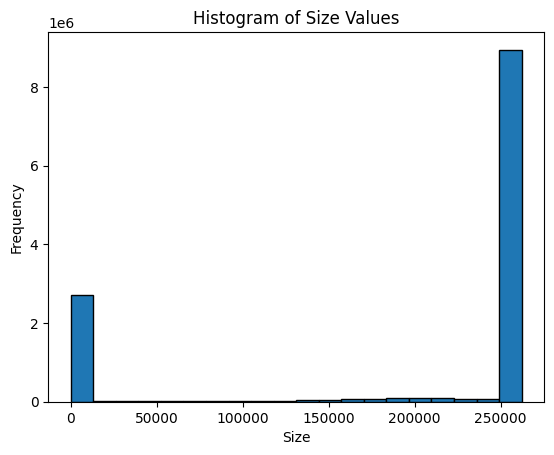

In [43]:
import matplotlib.pyplot as plt

# Assuming df is your DataFrame and 'size' is the column you want to plot
plt.hist(analyze_df.compute()['size'], bins=20, edgecolor='black')  # Adjust bins as needed
plt.xlabel('Size')
plt.ylabel('Frequency')
plt.title('Histogram of Size Values')
plt.show()

In [9]:
analyzer.file_hash.head()

,name,pid,tid,hhash,mount_point
hash,,,,,
1.0003791731677315e+19,/collab/usr/gapps/python/build/spack-toss4.1/v...,1481567,1481567,14200274195875936004,/collab/usr/gapps
1.0051724955523748e+19,/usr/WS2/haridev/iopp/venvs/dlio_venv/lib/pyth...,1481567,1481567,14200274195875936004,/usr/WS2
1.0070743794630304e+19,/collab/usr/gapps/python/build/spack-toss4.1/v...,1481567,1481567,14200274195875936004,/collab/usr/gapps
1.0071480435238796e+18,/usr/WS2/haridev/iopp/venvs/dlio_venv/lib/pyth...,1481567,1481567,14200274195875936004,/usr/WS2
1.0091750875713778e+19,/collab/usr/gapps/python/build/spack-toss4.1/v...,1481567,1481567,14200274195875936004,/collab/usr/gapps


In [19]:
analyzer.file_hash.loc["1.0003791731677315e+19", 'mount_point'].compute()

hash
1.0003791731677315e+19    /collab/usr/gapps
Name: mount_point, dtype: string

In [18]:
analyzer.events['mount_point'] = analyzer.file_hash.loc[analyzer.events.fhash, 'mount_point']

KeyError: 'Cannot index with non-boolean dask Series. Try passing computed values instead (e.g. ``ddf.loc[iindexer.compute()]``)'

In [33]:
result = dd.merge(analyzer.events, analyzer.file_hash[['mount_point']], left_on='fhash', right_index = True, how='left')

In [18]:
analyzer_montage.string_hash.head()

,name
hash,
14683.0,DEFAULT
14683.0,DEFAULT
14683.0,DEFAULT
14683.0,DEFAULT
14683.0,DEFAULT


In [ ]:
a = analyzer_montage.file_hash.reset_index().compute()

In [ ]:

# eventsDF = analyzer_montage.events[analyzer_montage.events['cat'] == "POSIX" ] # only posix events
# all_mounts = analyzer.file_hash['mount_point'].unique().compute()
# all_mounts[all_mounts.str.startswith('/')]

In [ ]:
IFCalculator = DFGrepInterference(analyzer_montage.events, app_name=app_name, cp_dir=cp_dir, existing=False)

In [ ]:
IFCalculator.get_degree()
IFCalculator.get_interference()

In [ ]:
IFCalculator.write_checkpoint("inter", cp_dir=cp_dir)